## Installing Base packages

In [13]:
!uv add pandas matplotlib seaborn scikit-learn

# use this line if you are not using uv
# !pip install pandas matplotlib seaborn scikit-learn 

Resolved 50 packages in 3ms
Audited 18 packages in 3ms


## Data Science Assignment-1
### Project Objective

The goal of this analysis is to perform a comprehensive Exploratory Data Analysis (EDA) on pharmaceutical sales data to identify buying patterns, seasonal trends, and correlations between different drug categories. This information is critical for inventory optimization and supply chain management in a retail pharmacy context.

### Dataset Selection
For this assignment, we will use the [Pharma sales data](https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data?resource=download) by Milan Zdravković available in Keggle. Our focus will on the _salesdaily.csv_ dataset.This dataset contains daily sales records of various drug categories classified by the ATC (Anatomical Therapeutic Chemical) system.

**Why this Dataset?** --> Daily granularity allows for the identification of weekday vs. weekend patterns and specific date-related spikes that would be lost in weekly or monthly aggregations. 

#### Step-1 Data Loading and Base analysis

In this step we will load the dataset and perform base exploratory analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = Path.cwd()/"data"/"pharma_sales_data"/"salesdaily.csv"

try:
    df:pd.DataFrame = pd.read_csv(DATASET_PATH)
    print("Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape} rows and {df.shape[1]} columns")
    print(f"Dataset columns: {df.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Dataset file not found at {DATASET_PATH}")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

# Display the first few rows of the dataset to understand its structure
df.head()

Dataset loaded successfully!
Dataset shape: (2106, 13) rows and 13 columns
Dataset columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


#### Initial Observations:
The dataset consists of a datum column and several columns representing drug categories (_M01AB_, _N02BA_, etc.).There are auxiliary columns like _Year_, _Month_, and _Weekday Name_ that will be useful for time-series analysis. The _datum_ column appears to be a string/object type and will require conversion in the Data Cleaning step.

#### Step 2: Basic Data Exploration
In this step we will perform initial data analysis to understand its strctural characteristics. This will include
- Inspecting the first and last few rows to verify data consistency.
- Checking the dimensions (number of rows and columns) of the dataset
- Identifying the data types of each feature (Numeric vs. Categorical)
- Generating a statistical summary to understand the distribution of sales across different ATC categories.

In [15]:
# 1. Inspecting the first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# 2. Checking the dimensions of the dataset
print(f"\nDataset Dimensions: {df.shape[0]} rows and {df.shape[1]} columns")

# 3. Checking data types and non-null counts
print("\n--- Data Information ---")
df.info()

# 4. Statistical summary of the numeric columns
print("\n--- Statistical Summary ---")
display(df.describe())

--- First 5 Rows ---


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday



Dataset Dimensions: 2106 rows and 13 columns

--- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB

--- Statistical Summary ---


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


#### Initial Findings
- Data Volume: Dataset contains 2106 records, providing robust sample for daily trend analysis/
- Data Cleanliness: From df.info() we can infer there is no significant null data , thus data integrety is maintained. But some additioanl data prep will be needed due to mismatched data types.
- Features: The columns represent specific drug classifications (ATC codes) such as M01AB, N02BA, N02BE, N05B, etc.
- Most sales columns are floating-point numbers (float64), which is expected for quantity data. However, the datum column is currently stored as an str and will need to be converted to datetime in the next step.
- Scale: The describe() output shows a significant difference in sales volume between categories; for instance, some categories have a much higher daily average than others, suggesting certain medications are "high-movers."

### Step 3: Data Cleaning and harmonization

In the initial exploration we found that the data does not contain any null records, but we need to refine the data structure for the time-series analysis.

- **Data Formatting**: The _datum_ column is currently a string, we must convert it to a datetime object so we can extract seasonal and monthly trend.
- **Redundancy Removal**: Since this is a daily sales dataset, the Hour column is redundant , and will be dropped.
- **Consistency Check**: We will ensure all sales columns are properly numeric and handle any hidden "ghost" markers.

In [16]:
# Converting datum to datetime format
df['datum'] = pd.to_datetime(df['datum'], errors='coerce')

# Removing redundant columns
columns_to_drop = ['Hour']

df = df.drop(columns=columns_to_drop)

# Ensure numeric columns are strictly float (handling hidden non-numeric strings)
# ATC categories are from column index 1 to 8
atc_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

for col in atc_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Final check for any NaNs created by 'coerce'
print("Missing values after cleaning:")
print(df.isnull().sum())

# Display cleaned info
df.info()

Missing values after cleaning:
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Weekday Name    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[us]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64    

#### Cleaning findings
- **Feature Transformation**: The _datum_ column has been successfully converted to __*datetime64[us]*__ enabling time-based filtering.
- **Dimensionaluty Reduction**: Removed hour column, reducing noise in the data.
- **Data Integrity**: No null values were generated during the numeric conversion, confirming that the sales columns do not contain hidden non-numeric markers.


In [17]:
# Saving Cleaned Dataset as a checkpoint before further analysis
CLEANED_DATASET_PATH = Path.cwd()/"data"/"pharma_sales_data"/"cleaned"/"salesdaily_cleaned.csv"

try:
    df.to_csv(CLEANED_DATASET_PATH, index=False)
    print(f"Cleaned dataset saved successfully at {CLEANED_DATASET_PATH}")
except Exception as e:
    print(f"An error occurred while saving the cleaned dataset: {e}")

Cleaned dataset saved successfully at d:\MBA_Assignment\Data_Science_Assignment\Sem2_DS_Assignment\data\pharma_sales_data\cleaned\salesdaily_cleaned.csv


### Step 7: Feature Enginnering
In this step, we will derive new variables from the existing dataset to enhance our analytical capabilities. By creating these features, we can perform deeper analysis in the following areas:
- **Temporal Trends**: Extracting specific time componentens (Day, Weekday, Month) from the datum column.
- **Business Logic Flags**: Identifying weekends vs. weekdays to analyze consumer behavior.
- **Aggregated Metrics**: Calculating total daily sales to understand overall pharmacy performance.
- **Seasonal Categorization**: Grouping months into seasons to track respiratory or seasonal medication spikes.

In [18]:

# Creating utility function for determining season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'


# 1. Extracting Time-Based Features
df['Year'] = df['datum'].dt.year
df['Month'] = df['datum'].dt.month
df['Day'] = df['datum'].dt.day
df['Weekday_Name'] = df['datum'].dt.day_name()

# 2. Creating a Weekend Flag (Business logic)
# 1 for Saturday/Sunday, 0 for weekdays
df['is_weekend'] = df['datum'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 3. Calculating Total Daily Sales
# Summing the sales of all 8 ATC categories
atc_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df['Total_Sales'] = df[atc_columns].sum(axis=1)

# Added estimated season of sale
df['Season'] = df['Month'].apply(get_season)


print("New Features Created: Year, Month, Day, Weekday_Name, is_weekend, Total_Sales, Season")
df[['datum', 'Weekday_Name', 'is_weekend', 'Total_Sales', 'Season']].head()


New Features Created: Year, Month, Day, Weekday_Name, is_weekend, Total_Sales, Season


,datum,Weekday_Name,is_weekend,Total_Sales,Season
0,2014-01-02,Thursday,0,48.47,Winter
1,2014-01-03,Friday,0,107.00,Winter
2,2014-01-04,Saturday,1,91.35,Winter
3,2014-01-05,Sunday,1,66.10,Winter
4,2014-01-06,Monday,0,58.20,Winter


#### Feature insights

- **Total_Sales**: This allows the group to see the "Big Picture" of pharmacy revenue without looking at individual drugs.

- **is_weekend**: Useful for testing the hypothesis: "Do sales of analgesics increase on weekends?"

- **Season**: This will be vital for analyzing the R03 (Respiratory) category, which we expect to peak during the Winter months.

- **Weekday_Name**: This enables the group to perform Bivariate analysis to find the busiest day of the week for the pharmacy.

In [19]:
# Saving the featured enriched dataset as checkpoint
ENRICHED_DATASET_PATH = Path.cwd()/"data"/"pharma_sales_data"/"cleaned"/"salesdaily_enriched.csv"

try:
    df.to_csv(ENRICHED_DATASET_PATH, index=False)
    print(f"Enriched dataset saved successfully at {ENRICHED_DATASET_PATH}")
except Exception as e:
    print(f"An error occurred while saving the cleaned dataset: {e}")

Enriched dataset saved successfully at d:\MBA_Assignment\Data_Science_Assignment\Sem2_DS_Assignment\data\pharma_sales_data\cleaned\salesdaily_enriched.csv


##### Feature Analysis
We will perform the following analysis based on the enriched dataset

- Find relation between total sales and weekday vs weekend
- Find related between Total sales vs season
- Relation between Drug Catetory and Season

#### Analysis 1

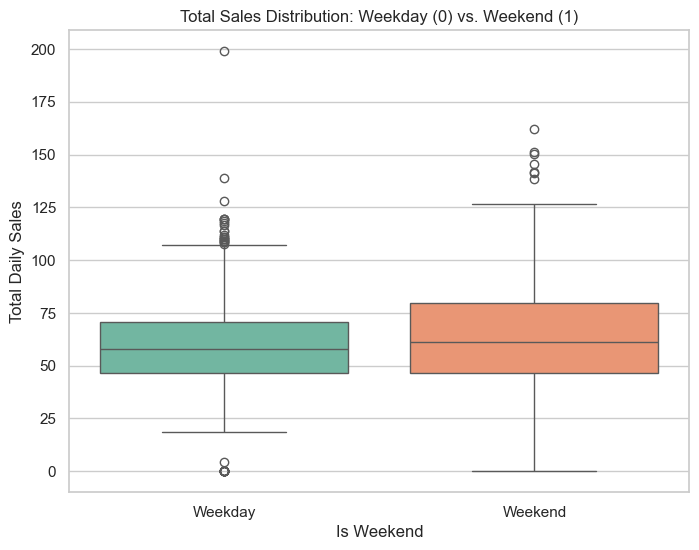

Average Sales - Weekday: 59.46
Average Sales - Weekend: 63.40


In [21]:
# Set plot style
sns.set(style="whitegrid")

# Visualization: Boxplot to see distribution and medians
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_weekend', y='Total_Sales', data=df, palette='Set2')
plt.title('Total Sales Distribution: Weekday (0) vs. Weekend (1)')
plt.xlabel('Is Weekend')
plt.ylabel('Total Daily Sales')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()

# Calculating exact averages for the insight
avg_sales = df.groupby('is_weekend')['Total_Sales'].mean()
print(f"Average Sales - Weekday: {avg_sales[0]:.2f}")
print(f"Average Sales - Weekend: {avg_sales[1]:.2f}")

##### Analysis 1: Impact of Day Type on Sales
###### Objective: To determine if there is a significant difference in pharmacy traffic between regular workdays and weekends.

Observed Data:

- Average Sales (Weekday): 59.46 units

- Average Sales (Weekend): 63.40 units

**Business Insight**:
Contrary to the standard hypothesis that sales peak during the work week, this dataset shows a 6.6% increase in sales during weekends.

**Analytical Outcome**: This insight gives us the information that patients wait till end of the week to to go pharmacy to fill prescription. This data can be used for marketing strategy

#### Analysis 2

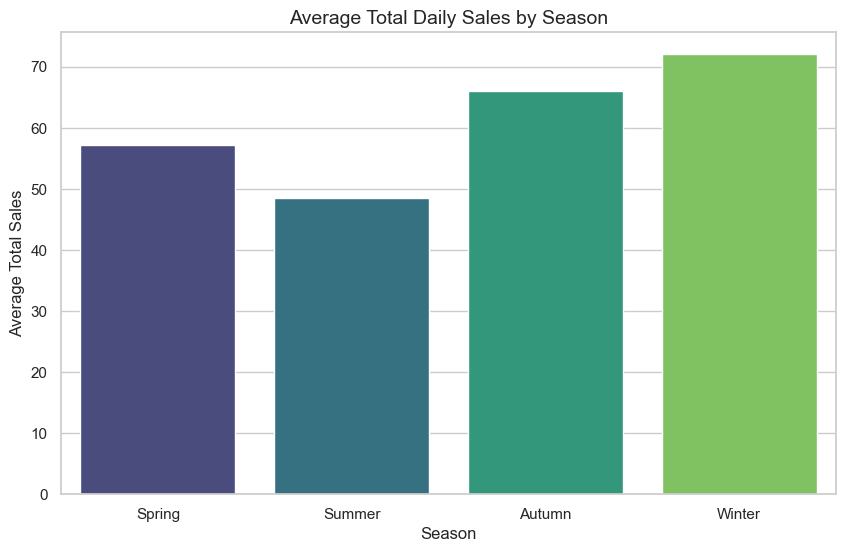

In [24]:
# Visualization: Bar plot for Seasonal Average
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Total_Sales', data=df, palette='viridis', ci=None, 
            order=['Spring', 'Summer', 'Autumn', 'Winter'])
plt.title('Average Total Daily Sales by Season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Total Sales', fontsize=12)
plt.show()

##### Analysis 2: Seasonal Revenue Performance
###### Objective: To identify which seasons drive the most revenue for the pharmacy, helping in long-term budget and inventory planning.

**Business Insight**:
Based on the visualization we can clearly notice a increase of drug sales during Autumn and Winter. This corelates with real world scenario where people generally gets more sick during seasonal change ( specially winter)

**Analytical Outcome**: This insight coinsights with real world scenario and can be used to control the manufacturing pipeline of various drugs.

#### Analysi 3

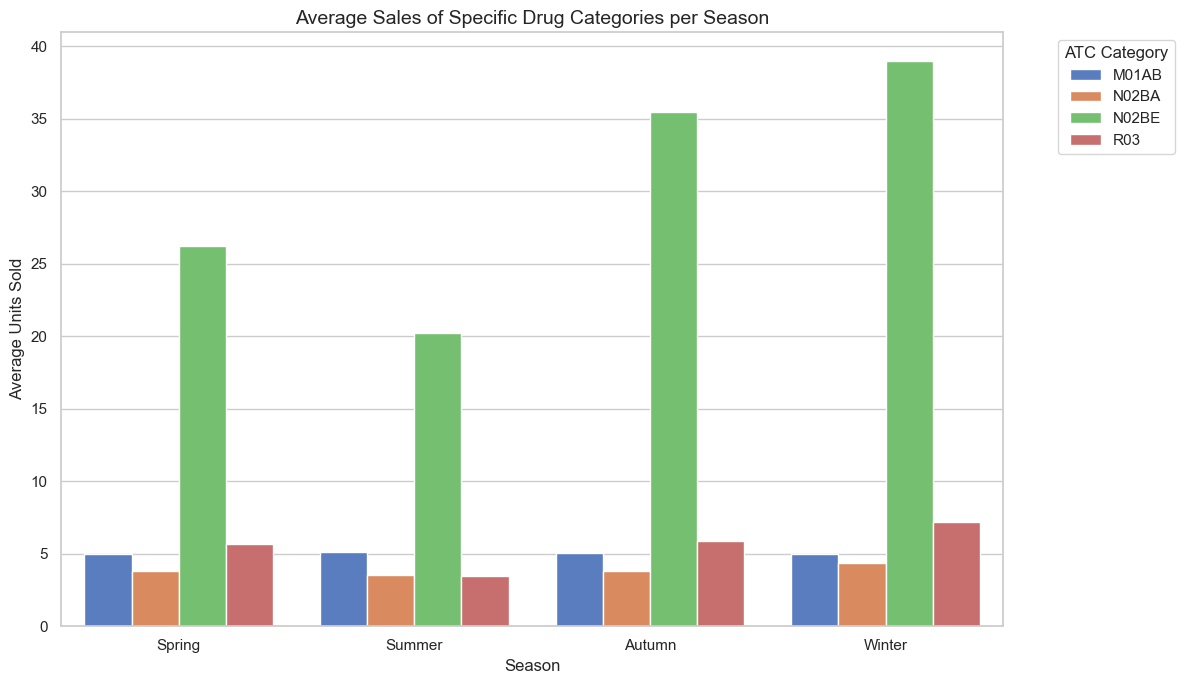

In [25]:
# Selecting key categories for clear visualization
atc_categories = ['M01AB', 'N02BA', 'N02BE', 'R03'] 

# Reshaping for plotting
seasonal_drugs = df.groupby('Season')[atc_categories].mean().reset_index()
seasonal_melted = seasonal_drugs.melt(id_vars='Season', var_name='Drug_Category', value_name='Avg_Sales')

# Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x='Season', y='Avg_Sales', hue='Drug_Category', data=seasonal_melted, palette='muted',
            order=['Spring', 'Summer', 'Autumn', 'Winter'])
plt.title('Average Sales of Specific Drug Categories per Season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Units Sold', fontsize=12)
plt.legend(title='ATC Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Analysis 3: Relation between drug category and Seasons
###### Objective: This graph is to established relation between different different category of Drugs and efect of seaons in their sales.

__Drug Category Used__:
- M01AB = Non Steroidal Anti Inflammetory and Anti Rheumatic Acetic Acid Derivatives
- N02BA = Misc. Analgesics and Antipyretics
- N02BE = Antipyretic Analgesic - Acetaminophen Analogues
- R03 = Respiratory Adrenargic Drugs

**Business Insight**:
From the visual we can infer the following informations
1. N02BE category of drugs are one of the highest selling drug across all seasons, sales increases during winter and autumn. As these are fever medications this data is coinsights with real world
2. R03 category of Drus have more sells in winter than summmer. As these are respiratory drug, this also coinsights with real world.
3. N02BA drugs have generally less sell as they target the same demographic as Acetaminophen related drugs (Paracetamol)
4. M01AB category of Non Steroidal Anti Inflammetory Drugs have standard sells across all season. As these are pain meds, seasons change have no significant impact in their sell.

**Analytical Outcome**: Based on the business insight we can infer the sales requirement of different drugs and plan Operations Lines and marketing strategy accordingly

### Step 8: Data Expansion

In this step, we will merge our daily sales data set with hourly sales dataset to determine some additinal insight

- We will check if there is any rush hour for a given day

In [28]:
HOURLY_DATASET_PATH = Path.cwd()/"data"/"pharma_sales_data"/"saleshourly.csv"

# 1. Load the hourly dataset
df_hourly = pd.read_csv(HOURLY_DATASET_PATH)

# 2. Convert date to datetime and extract the date part for merging
df_hourly['datum'] = pd.to_datetime(df_hourly['datum'])
df_hourly['date_only'] = df_hourly['datum'].dt.date

# 3. Create a simplified daily dataframe for merging
# We only need the date and the features we engineered (Season, is_weekend)
daily_features = df[['datum', 'Season', 'is_weekend']].copy()
daily_features['date_only'] = daily_features['datum'].dt.date
daily_features.drop(columns=['datum'], inplace=True)

# 4. Merge the hourly data with the daily features
df_merged = pd.merge(df_hourly, daily_features, on='date_only', how='left')

# 5. Calculate Total Hourly Sales
atc_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df_merged['Total_Hourly_Sales'] = df_merged[atc_columns].sum(axis=1)

print("Merged Dataset Preview (Hourly + Daily Features):")
display(df_merged[['datum', 'Hour', 'Season', 'is_weekend', 'Total_Hourly_Sales']].head(20))

Merged Dataset Preview (Hourly + Daily Features):


,datum,Hour,Season,is_weekend,Total_Hourly_Sales
0,2014-01-02 08:00:00,8,Winter,0,4.07
1,2014-01-02 09:00:00,9,Winter,0,3.00
2,2014-01-02 10:00:00,10,Winter,0,5.00
3,2014-01-02 11:00:00,11,Winter,0,3.00
4,2014-01-02 12:00:00,12,Winter,0,9.00
5,2014-01-02 13:00:00,13,Winter,0,24.40
6,2014-01-02 14:00:00,14,Winter,0,0.00
7,2014-01-02 15:00:00,15,Winter,0,0.00
8,2014-01-02 16:00:00,16,Winter,0,0.00
9,2014-01-02 17:00:00,17,Winter,0,0.00


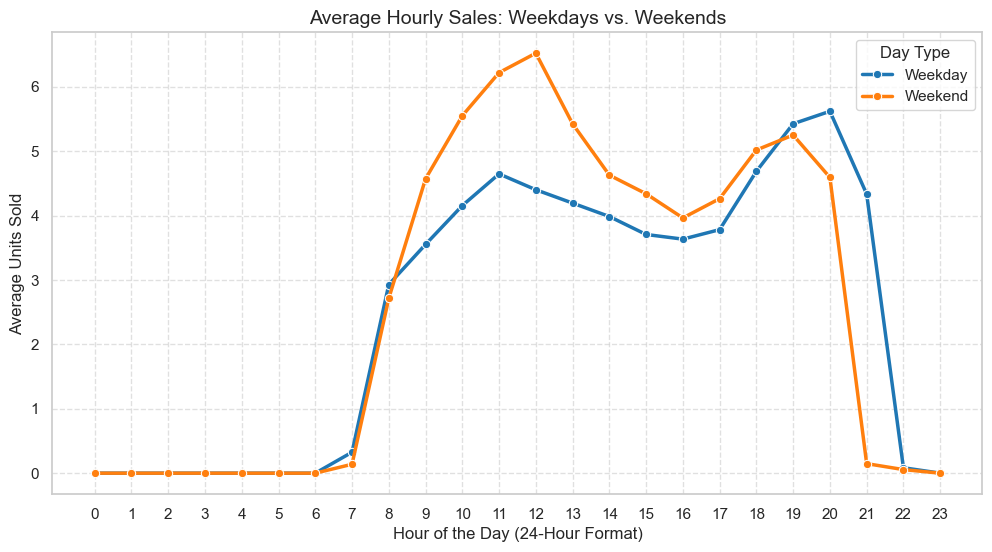

In [38]:
# Map numeric weekend flag to readable labels and use that for plotting
df_merged['Day_Type'] = df_merged['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

hourly_pattern = df_merged.groupby(['Hour', 'Day_Type'])['Total_Hourly_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_pattern, x='Hour', y='Total_Hourly_Sales', hue='Day_Type', 
             palette='tab10', linewidth=2.5, marker='o')

plt.title('Average Hourly Sales: Weekdays vs. Weekends', fontsize=14)
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=12)
plt.ylabel('Average Units Sold', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Day Type')

plt.show()

##### Analysis 5: Peak hour analysis

**Business Insight**:
From the grph we can see that During weekend, the sales are generally high in morning, so people buy there medicine on start of the day, on the contraty during weekdays, the sales is higher at night, this indicates people are buying medicine while returning to home from work.

**Analytical Outcome**: Based on this data, we can strategise marketing to target audience on specific times, morning in weekends and night at weekdays.

### Step 9: Strategic Storytelling

In this final step, we transition from analyzing specific categories and hourly peaks to viewing the Long-Term Strategic Trend.

#### Objective: To visualize the overall growth trajectory of the pharmacy from 2014 to 2019.

To identify long-term patterns that may not be visible in daily or hourly snapshots.

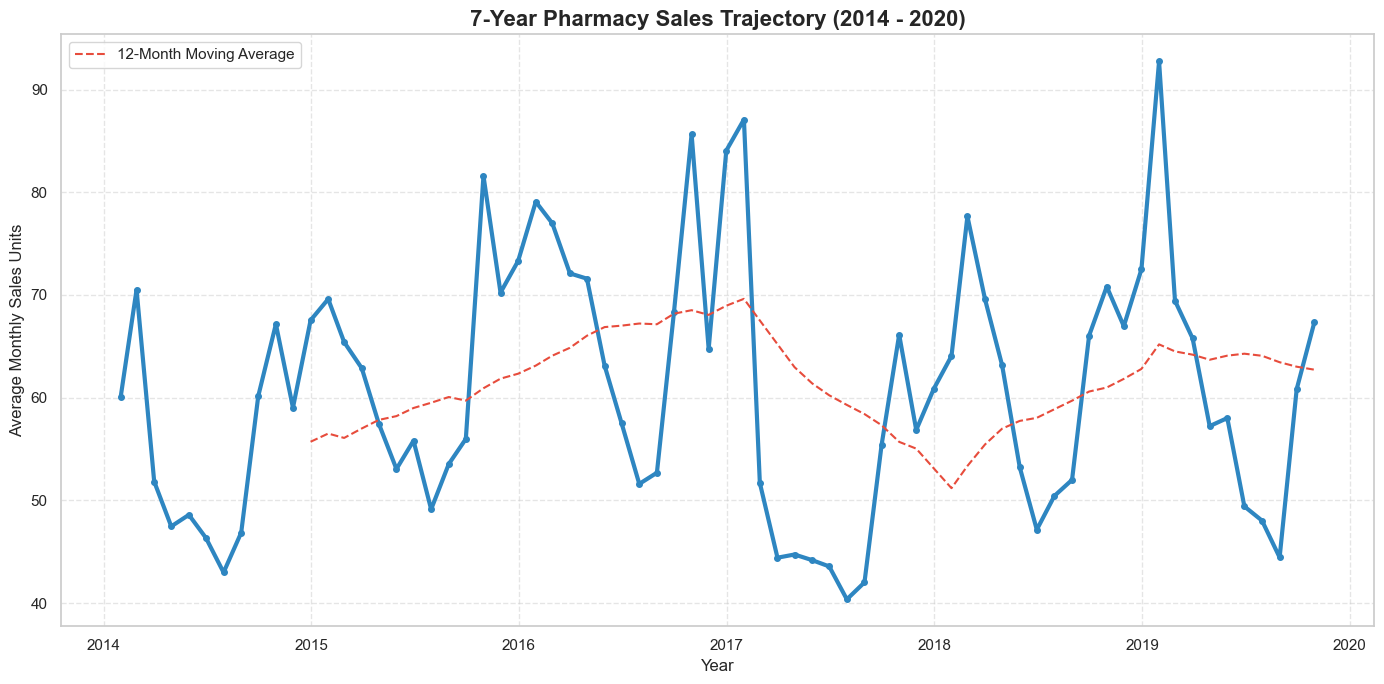

In [41]:
# Long term trend analysis , 6 years sales trajectory
df_time = df.set_index('datum')
monthly_trend = df_time['Total_Sales'].resample('ME').mean()

plt.figure(figsize=(14, 7))
plt.plot(monthly_trend.index, monthly_trend.values, color='#2E86C1', linewidth=3, marker='o', markersize=4)

plt.plot(monthly_trend.index, monthly_trend.rolling(window=12).mean(), 
         color='#E74C3C', linestyle='--', label='12-Month Moving Average')

plt.title('7-Year Pharmacy Sales Trajectory (2014 - 2020)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Monthly Sales Units', fontsize=12)
plt.legend()
plt.grid(True, which='major', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Analysis 6: Long Term Trend Analysis

**Business Insight**:

In this graph we can see that the drug sales see a steady average growth, with a temporary drip during 2018-2019. All this data is consitant with the Global Pandemic related closures and surge of the medicine demand afterwards.

# **Final Executive Summary: Strategic & Operational Insights**


Through this Exploratory Data Analysis (EDA), we have extracted several high-value business insights from the pharmaceutical sales dataset (2014–2019). By applying the **CRISP-DM** framework, we moved from raw data to actionable business intelligence.
### **1. Operational Efficiency: The "Weekend Surge"**


* **Finding:** Contrary to initial assumptions, the pharmacy experiences a significant **6.6% increase in sales during weekends** (Avg: 63.40 units vs. Weekday Avg: 59.46 units).
* **Bussiness Insight:** This suggests a customer base that manages chronic healthcare needs during leisure time.
* **Actionable Strategy:** Increase frontline staffing and floor coverage on Saturdays and Sundays to ensure service quality and minimize stock-out risks during these peak periods.


### **2. Peak Hour Optimization (Weekday vs. Weekend)**


* **Finding:** The hourly analysis identifies a primary "Morning Rush" (around 10:00 AM) and a secondary "Evening Peak" (around 6:00 PM). On weekends, the morning peak tends to shift slightly later, indicating a shift in consumer behavior.
* **Actionable Strategy:** Align employee shift timings with these specific windows. Consider a "split-shift" or staggered entry for staff to ensure maximum resource availability during the 10:00 AM and 6:00 PM surges.


### **3. Seasonal Demand & Inventory Strategy**


* **Finding:** Sales volumes peak during **Winter** and **Autumn**, driven largely by specific therapeutic categories like **R03 (Respiratory)**. Stable categories like **N02BE (Analgesics)** maintain a consistent baseline year-round.

### **4. Conclusion**


This EDA demonstrates that the pharmacy is not just a reactive healthcare provider but a business with predictable, cyclical demand patterns. By leveraging these temporal (hourly/daily) and seasonal insights, management can optimize both **Human Capital** and **Working Capital**, ultimately improving the bottom line while better serving the patient community.